# Task 2

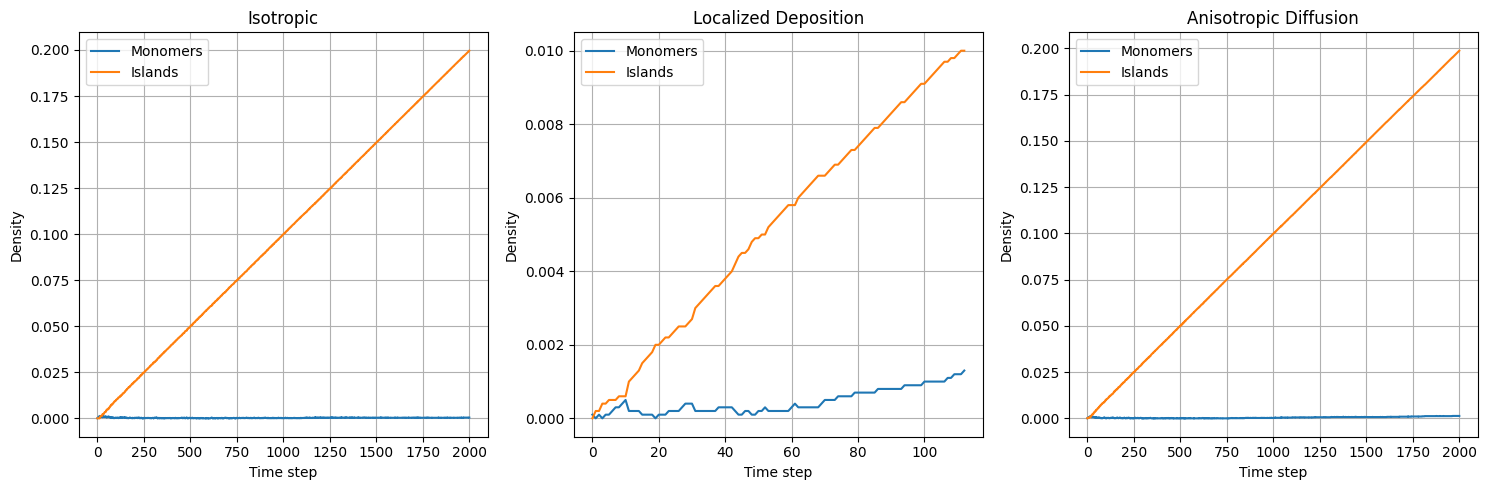

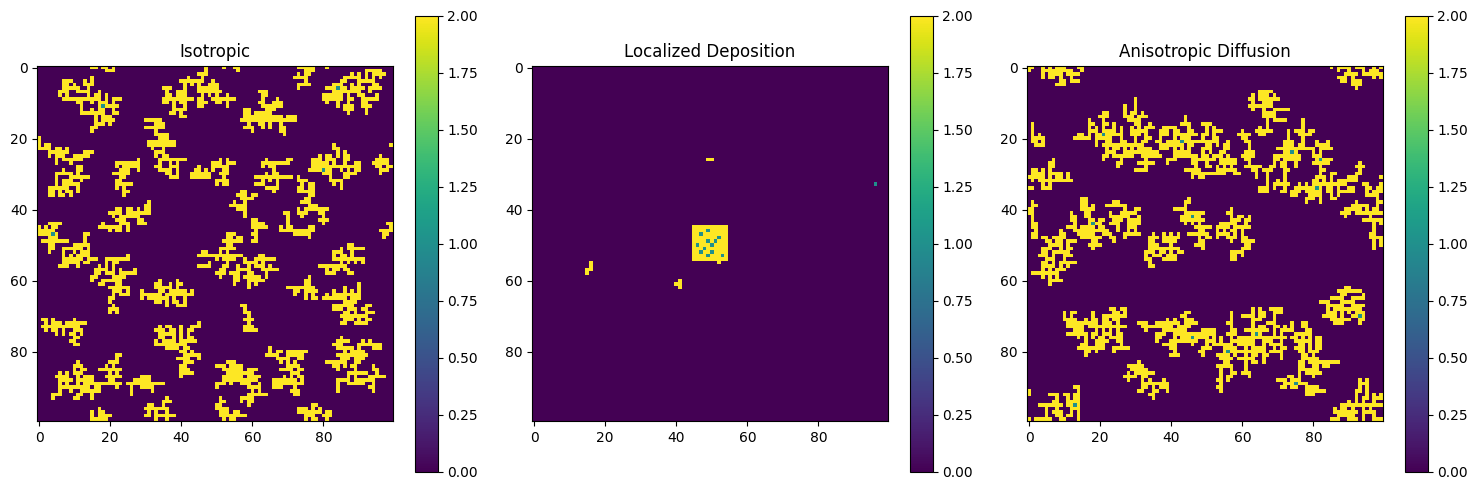

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

class ParticleSimulation:
    def __init__(self, L, Ndif, coverage_limit=0.2, case_type="isotropic", l=None):
        self.L = L
        self.grid = np.zeros((L, L), dtype=int)
        self.coverage_limit = coverage_limit
        self.case_type = case_type
        
        # Handle different Ndif cases
        if isinstance(Ndif, tuple):
            self.Ndif_x, self.Ndif_y = Ndif
        else:
            self.Ndif_x = self.Ndif_y = Ndif
            
        # Set deposition area for localized case
        if case_type == "localized":
            self.l = l if l is not None else L // 10
            self.start_x = (L - self.l) // 2
            self.start_y = (L - self.l) // 2
        
        self.time_evolution = {
            'monomer_density': [],
            'island_density': [],
            'coverage': []
        }
    
    def get_coverage(self):
        return np.sum(self.grid > 0) / (self.L * self.L)
    
    def deposit_monomer(self):
        if self.get_coverage() >= self.coverage_limit:
            return False
            
        if self.case_type == "localized":
            empty_sites = np.where(
                (self.grid[self.start_x:self.start_x+self.l, 
                          self.start_y:self.start_y+self.l] == 0)
            )
            if len(empty_sites[0]) > 0:
                idx = np.random.randint(len(empty_sites[0]))
                x = self.start_x + empty_sites[0][idx]
                y = self.start_y + empty_sites[1][idx]
                self.grid[x, y] = 1
                return True
        else:
            empty_sites = np.where(self.grid == 0)
            if len(empty_sites[0]) > 0:
                idx = np.random.randint(len(empty_sites[0]))
                x, y = empty_sites[0][idx], empty_sites[1][idx]
                self.grid[x, y] = 1
                return True
        return False
    
    def diffuse_monomers(self):
        monomer_positions = np.where(self.grid == 1)
        for idx in range(len(monomer_positions[0])):
            x, y = monomer_positions[0][idx], monomer_positions[1][idx]
            
            if self.grid[x, y] != 1:
                continue
            
            # X-direction diffusion
            for _ in range(self.Ndif_x):
                if np.random.random() < 0.5:
                    new_x = (x + np.random.choice([-1, 1])) % self.L
                    if self.grid[new_x, y] == 0:
                        self.grid[x, y] = 0
                        self.grid[new_x, y] = 1
                        x = new_x
                        if self.check_aggregation(x, y):
                            break
            
            # Y-direction diffusion
            if self.grid[x, y] == 1:  # Only if still a monomer
                for _ in range(self.Ndif_y):
                    if np.random.random() < 0.5:
                        new_y = (y + np.random.choice([-1, 1])) % self.L
                        if self.grid[x, new_y] == 0:
                            self.grid[x, y] = 0
                            self.grid[x, new_y] = 1
                            y = new_y
                            if self.check_aggregation(x, y):
                                break
    
    def check_aggregation(self, x, y):
        neighbors = [
            ((x+1)%self.L, y),
            ((x-1)%self.L, y),
            (x, (y+1)%self.L),
            (x, (y-1)%self.L)
        ]
        
        for nx, ny in neighbors:
            if self.grid[nx, ny] in [1, 2]:
                self.grid[x, y] = 2
                self.grid[nx, ny] = 2
                return True
        return False
    
    def get_densities(self):
        total_sites = self.L * self.L
        monomer_density = np.sum(self.grid == 1) / total_sites
        island_density = np.sum(self.grid == 2) / total_sites
        return monomer_density, island_density
    
    def run_simulation(self, steps):
        for step in range(steps):
            if not self.deposit_monomer():
                break
            self.diffuse_monomers()
            
            m_dens, i_dens = self.get_densities()
            self.time_evolution['monomer_density'].append(m_dens)
            self.time_evolution['island_density'].append(i_dens)
            self.time_evolution['coverage'].append(self.get_coverage())

# Function to run simulations for different cases
def run_all_cases(L=100, steps=10000):
    # Case 1: Isotropic
    sim_iso = ParticleSimulation(L=L, Ndif=100, case_type="isotropic")
    sim_iso.run_simulation(steps)
    
    # Case 2: Localized deposition
    sim_loc = ParticleSimulation(L=L, Ndif=100, case_type="localized")
    sim_loc.run_simulation(steps)
    
    # Case 3: Anisotropic diffusion
    sim_aniso = ParticleSimulation(L=L, Ndif=(1000, 10), case_type="anisotropic")
    sim_aniso.run_simulation(steps)
    
    return sim_iso, sim_loc, sim_aniso

# Run simulations and create plots
L = 100
steps = 10000
sim_iso, sim_loc, sim_aniso = run_all_cases(L, steps)

# Plot time evolution for all cases
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
cases = [sim_iso, sim_loc, sim_aniso]
titles = ['Isotropic', 'Localized Deposition', 'Anisotropic Diffusion']

for idx, (sim, title) in enumerate(zip(cases, titles)):
    axs[idx].plot(sim.time_evolution['monomer_density'], label='Monomers')
    axs[idx].plot(sim.time_evolution['island_density'], label='Islands')
    axs[idx].set_xlabel('Time step')
    axs[idx].set_ylabel('Density')
    axs[idx].set_title(title)
    axs[idx].legend()
    axs[idx].grid(True)

plt.tight_layout()
plt.show()

# Plot final configurations
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for idx, (sim, title) in enumerate(zip(cases, titles)):
    im = axs[idx].imshow(sim.grid, cmap='viridis')
    axs[idx].set_title(title)
    plt.colorbar(im, ax=axs[idx])

plt.tight_layout()
plt.show()